In [2]:
import pandas as pd

In [6]:
memmbers = pd.read_csv("dataset\loyalty_members.csv")
orders = pd.read_csv("dataset\orders.csv")
order_details = pd.read_csv("dataset\order_details.csv")

<>:1: SyntaxWarning: invalid escape sequence '\l'
<>:2: SyntaxWarning: invalid escape sequence '\o'
<>:3: SyntaxWarning: invalid escape sequence '\o'
<>:1: SyntaxWarning: invalid escape sequence '\l'
<>:2: SyntaxWarning: invalid escape sequence '\o'
<>:3: SyntaxWarning: invalid escape sequence '\o'
C:\Users\nolan\AppData\Local\Temp\ipykernel_35408\200881336.py:1: SyntaxWarning: invalid escape sequence '\l'
  memmbers = pd.read_csv("dataset\loyalty_members.csv")
C:\Users\nolan\AppData\Local\Temp\ipykernel_35408\200881336.py:2: SyntaxWarning: invalid escape sequence '\o'
  orders = pd.read_csv("dataset\orders.csv")
C:\Users\nolan\AppData\Local\Temp\ipykernel_35408\200881336.py:3: SyntaxWarning: invalid escape sequence '\o'
  order_details = pd.read_csv("dataset\order_details.csv")


In [4]:
memmbers

,loyalty_id,email,tier,points_earned,gender,age,birthday,occupation,name
0,L000002,noah.wilson1@yahoo.com,Frequent,6415,Male,28,1997-03-18,Electrician,Noah Wilson
1,L000005,layla.gonzalez4@icloud.com,Frequent,5245,Female,33,1992-02-18,Software Engineer,Layla Gonzalez
2,L000009,mila.nowak8@yahoo.com,Frequent,7047,Male,25,2000-08-13,Graphic Designer,Mila Nowak
3,L000010,alexander.lau9@hotmail.com,Very Frequent,8769,Male,31,1994-07-16,Project Manager,Alexander Lau
4,L000011,aria.nowak10@icloud.com,Frequent,5417,Female,27,1998-08-26,Barista,Aria Nowak
...,...,...,...,...,...,...,...,...,...
303,L000494,aiden.smith493@outlook.com,Frequent,6683,Male,31,1994-12-02,Student,Aiden Smith
304,L000496,wyatt.su495@icloud.com,Very Frequent,13498,Non-binary,21,2004-04-04,Research Assistant,Wyatt Su
305,L000497,mia.chow496@icloud.com,Very Frequent,14762,Prefer not to say,35,1990-02-06,Accountant,Mia Chow
306,L000499,benjamin.lau498@gmail.com,Very Frequent,11761,Prefer not to say,24,2001-02-03,Research Assistant,Benjamin Lau


In [5]:
orders

,transaction_id,email,transaction_date,time_spent_min,total_bill_amount
0,T000001,mason.chan230@icloud.com,2024-10-28,151,137.94
1,T000002,layla.lam324@icloud.com,2024-10-28,98,71.94
2,T000003,aiden.lam185@hotmail.com,2024-10-28,115,55.45
3,T000004,riley.su43@yahoo.com,2024-10-28,102,147.20
4,T000005,zoey.su268@hotmail.com,2024-10-28,101,160.41
...,...,...,...,...,...
4495,T004496,emma.su325@yahoo.com,2025-10-28,100,34.76
4496,T004497,chloe.wilson133@hotmail.com,2025-10-28,114,56.26
4497,T004498,evelyn.white385@outlook.com,2025-10-28,140,143.70
4498,T004499,oliver.wang362@gmail.com,2025-10-28,80,95.75


In [ ]:
fields = [
    "item_type",
    "item_id",
    "item_name",
    "category",
    "unit_price_cad",
    "quantity",
    "line_amount_cad",
]

order_details_subset = order_details[["transaction_id", *fields]].copy()

items_by_txn = (
    order_details_subset
    .groupby("transaction_id", sort=False)[fields]
    .apply(lambda df: df.to_dict(orient="records"))
)

orders = orders.copy()
orders["order_details"] = orders["transaction_id"].map(items_by_txn)

orders.head()

# order_details is a list of dicts, where each dict is an item of the transaction


,transaction_id,email,transaction_date,time_spent_min,total_bill_amount,order_details
0,T000001,mason.chan230@icloud.com,2024-10-28,151,137.94,"[{'item_type': 'food', 'item_id': 'F004', 'ite..."
1,T000002,layla.lam324@icloud.com,2024-10-28,98,71.94,"[{'item_type': 'food', 'item_id': 'F008', 'ite..."
2,T000003,aiden.lam185@hotmail.com,2024-10-28,115,55.45,"[{'item_type': 'food', 'item_id': 'F009', 'ite..."
3,T000004,riley.su43@yahoo.com,2024-10-28,102,147.20,"[{'item_type': 'food', 'item_id': 'F006', 'ite..."
4,T000005,zoey.su268@hotmail.com,2024-10-28,101,160.41,"[{'item_type': 'food', 'item_id': 'F002', 'ite..."


In [15]:
orders["transaction_date"] = pd.to_datetime(orders["transaction_date"])
orders["weekday"] = orders["transaction_date"].dt.day_name()

orders.head()


,transaction_id,email,transaction_date,time_spent_min,total_bill_amount,order_details,weekday
0,T000001,mason.chan230@icloud.com,2024-10-28,151,137.94,"[{'item_type': 'food', 'item_id': 'F004', 'ite...",Monday
1,T000002,layla.lam324@icloud.com,2024-10-28,98,71.94,"[{'item_type': 'food', 'item_id': 'F008', 'ite...",Monday
2,T000003,aiden.lam185@hotmail.com,2024-10-28,115,55.45,"[{'item_type': 'food', 'item_id': 'F009', 'ite...",Monday
3,T000004,riley.su43@yahoo.com,2024-10-28,102,147.20,"[{'item_type': 'food', 'item_id': 'F006', 'ite...",Monday
4,T000005,zoey.su268@hotmail.com,2024-10-28,101,160.41,"[{'item_type': 'food', 'item_id': 'F002', 'ite...",Monday


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

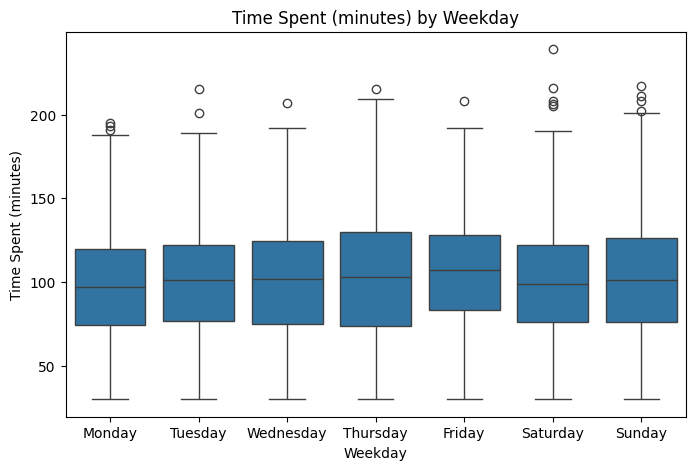

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(data=orders, x="weekday", y="time_spent_min", order=["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"])
plt.title("Time Spent (minutes) by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Time Spent (minutes)")
plt.show()


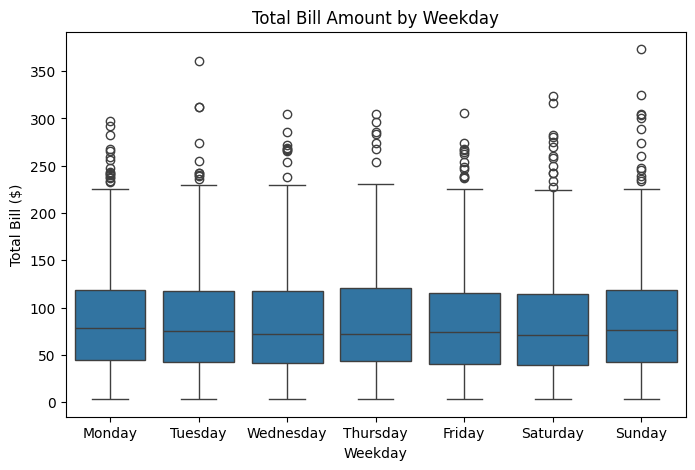

In [30]:
plt.figure(figsize=(8,5))
sns.boxplot(data=orders, x="weekday", y="total_bill_amount", order=["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"])
plt.title("Total Bill Amount by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Total Bill ($)")
plt.show()


In [40]:
customer = pd.read_csv("dataset\customers.csv")

<>:1: SyntaxWarning: invalid escape sequence '\c'
<>:1: SyntaxWarning: invalid escape sequence '\c'
C:\Users\nolan\AppData\Local\Temp\ipykernel_35408\466506330.py:1: SyntaxWarning: invalid escape sequence '\c'
  customer = pd.read_csv("dataset\customers.csv")


In [43]:
members = pd.read_csv("dataset\loyalty_members.csv")

<>:1: SyntaxWarning: invalid escape sequence '\l'
<>:1: SyntaxWarning: invalid escape sequence '\l'
C:\Users\nolan\AppData\Local\Temp\ipykernel_35408\2272696117.py:1: SyntaxWarning: invalid escape sequence '\l'
  members = pd.read_csv("dataset\loyalty_members.csv")


In [47]:
customers = pd.read_csv("dataset\customers.csv")

<>:1: SyntaxWarning: invalid escape sequence '\c'
<>:1: SyntaxWarning: invalid escape sequence '\c'
C:\Users\nolan\AppData\Local\Temp\ipykernel_35408\2911203539.py:1: SyntaxWarning: invalid escape sequence '\c'
  customers = pd.read_csv("dataset\customers.csv")


In [48]:
customers['loyalty_enrolled'].value_counts()

loyalty_enrolled
Y    308
N    192
Name: count, dtype: int64

In [49]:
members['tier'].value_counts()

tier
Frequent         179
Very Frequent    126
Casual             3
Name: count, dtype: int64

In [50]:
# Extract email provider (the part between @ and .)
customers["email_provider"] = customers["email"].str.split("@").str[1].str.split(".").str[0]

# Compare loyalty enrollment by email provider
loyalty_by_provider = customers.groupby("email_provider")["loyalty_enrolled"].apply(
    lambda x: pd.Series({
        "total": len(x),
        "enrolled": (x == "Y").sum(),
        "not_enrolled": (x == "N").sum(),
        "enrollment_rate": (x == "Y").mean() * 100
    })
).unstack()

# Sort by enrollment rate
loyalty_by_provider = loyalty_by_provider.sort_values("enrollment_rate", ascending=False)

print("Loyalty Enrollment by Email Provider:")
print(loyalty_by_provider.round(2))


Loyalty Enrollment by Email Provider:
                total  enrolled  not_enrolled  enrollment_rate
email_provider                                                
yahoo           104.0      69.0          35.0            66.35
hotmail         105.0      68.0          37.0            64.76
gmail            85.0      54.0          31.0            63.53
outlook         111.0      64.0          47.0            57.66
icloud           95.0      53.0          42.0            55.79


In [51]:
# Extract email provider (the part between @ and .)
members["email_provider"] = members["email"].str.split("@").str[1].str.split(".").str[0]

# Compare loyalty tier by email provider
tier_by_provider = members.groupby("email_provider")["tier"].apply(
    lambda x: pd.Series({
        "total": len(x),
        "Casual": (x == "Casual").sum(),
        "Frequent": (x == "Frequent").sum(),
        "Very Frequent": (x == "Very Frequent").sum(),
        "casual_rate": (x == "Casual").mean() * 100,
        "frequent_rate": (x == "Frequent").mean() * 100,
        "very_frequent_rate": (x == "Very Frequent").mean() * 100
    })
).unstack()

# Sort by Very Frequent rate (highest tier)
tier_by_provider = tier_by_provider.sort_values("very_frequent_rate", ascending=False)

print("Loyalty Tier Distribution by Email Provider:")
print(tier_by_provider.round(2))


Loyalty Tier Distribution by Email Provider:
                total  Casual  Frequent  Very Frequent  casual_rate  \
email_provider                                                        
icloud           53.0     0.0      27.0           26.0         0.00   
outlook          64.0     0.0      37.0           27.0         0.00   
hotmail          68.0     1.0      39.0           28.0         1.47   
gmail            54.0     0.0      34.0           20.0         0.00   
yahoo            69.0     2.0      42.0           25.0         2.90   

                frequent_rate  very_frequent_rate  
email_provider                                     
icloud                  50.94               49.06  
outlook                 57.81               42.19  
hotmail                 57.35               41.18  
gmail                   62.96               37.04  
yahoo                   60.87               36.23  


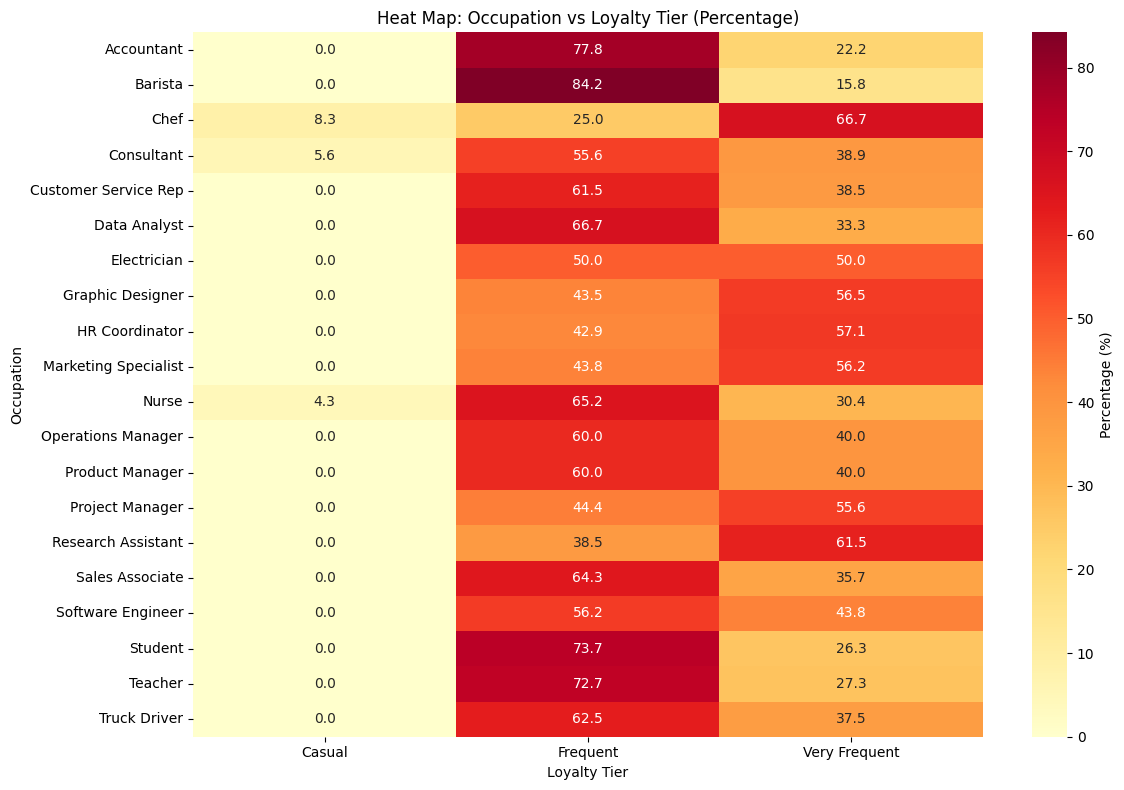

In [53]:
# Create a crosstab of occupation vs tier
occupation_tier_crosstab = pd.crosstab(members["occupation"], members["tier"])

# Normalize by rows (percentage of each occupation in each tier)
occupation_tier_percentage = occupation_tier_crosstab.div(occupation_tier_crosstab.sum(axis=1), axis=0) * 100

# Create heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(occupation_tier_percentage, annot=True, fmt=".1f", cmap="YlOrRd", cbar_kws={"label": "Percentage (%)"})
plt.title("Heat Map: Occupation vs Loyalty Tier (Percentage)")
plt.xlabel("Loyalty Tier")
plt.ylabel("Occupation")
plt.tight_layout()
plt.show()


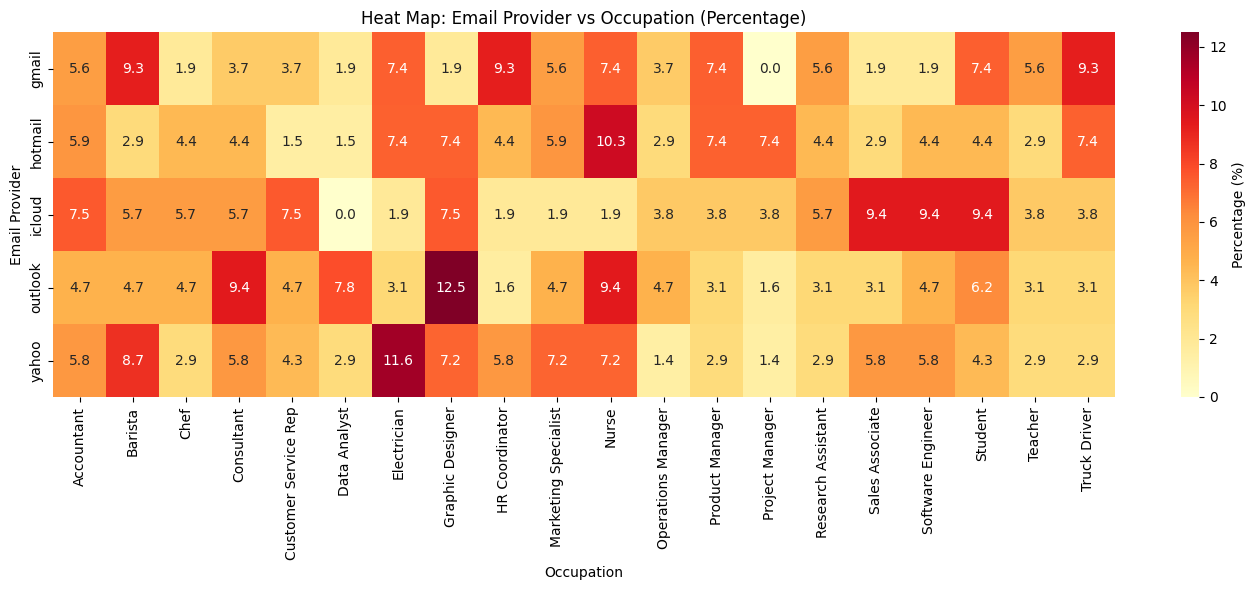

In [54]:
# Create a crosstab of email provider vs occupation
provider_occupation_crosstab = pd.crosstab(members["email_provider"], members["occupation"])

# Normalize by rows (percentage of each email provider in each occupation)
provider_occupation_percentage = provider_occupation_crosstab.div(provider_occupation_crosstab.sum(axis=1), axis=0) * 100

# Create heatmap
plt.figure(figsize=(14, 6))
sns.heatmap(provider_occupation_percentage, annot=True, fmt=".1f", cmap="YlOrRd", cbar_kws={"label": "Percentage (%)"})
plt.title("Heat Map: Email Provider vs Occupation (Percentage)")
plt.xlabel("Occupation")
plt.ylabel("Email Provider")
plt.tight_layout()
plt.show()


In [55]:
# Merge orders with members to get tier information
orders_with_tier = orders.merge(members[["email", "tier"]], on="email", how="inner")

print(f"Orders with tier information: {len(orders_with_tier)}")
print(f"Total orders: {len(orders)}")
print(f"\nTier distribution in orders:")
print(orders_with_tier["tier"].value_counts())

orders_with_tier.head()


Orders with tier information: 2791
Total orders: 4500

Tier distribution in orders:
tier
Very Frequent    1428
Frequent         1356
Casual              7
Name: count, dtype: int64


,transaction_id,email,transaction_date,time_spent_min,total_bill_amount,order_details,weekday,tier
0,T000001,mason.chan230@icloud.com,2024-10-28,151,137.94,"[{'item_type': 'food', 'item_id': 'F004', 'ite...",Monday,Frequent
1,T000004,riley.su43@yahoo.com,2024-10-28,102,147.20,"[{'item_type': 'food', 'item_id': 'F006', 'ite...",Monday,Very Frequent
2,T000005,zoey.su268@hotmail.com,2024-10-28,101,160.41,"[{'item_type': 'food', 'item_id': 'F002', 'ite...",Monday,Frequent
3,T000006,oliver.wang362@gmail.com,2024-10-28,67,9.99,"[{'item_type': 'drink', 'item_id': 'D005', 'it...",Monday,Very Frequent
4,T000007,elijah.nowak196@yahoo.com,2024-10-28,110,77.69,"[{'item_type': 'food', 'item_id': 'F011', 'ite...",Monday,Very Frequent


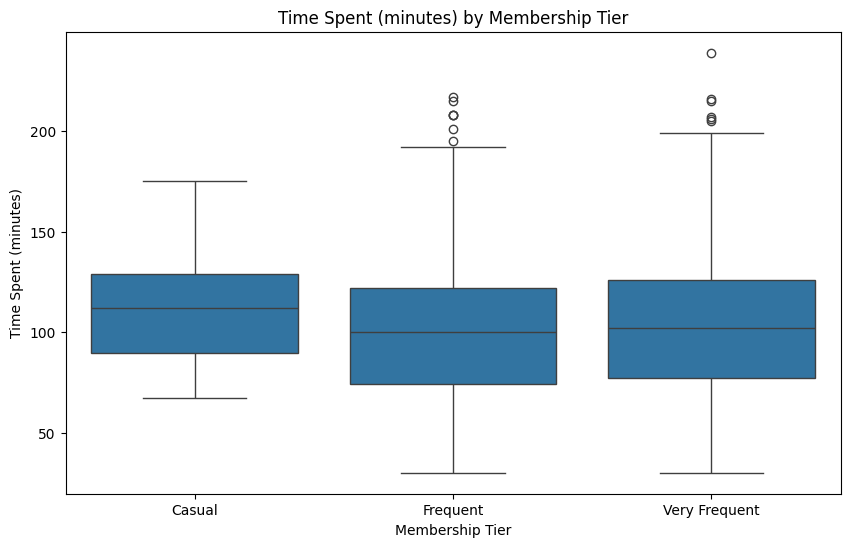

In [56]:
# Boxplot: Time Spent by Membership Tier
plt.figure(figsize=(10, 6))
tier_order = ["Casual", "Frequent", "Very Frequent"]
sns.boxplot(data=orders_with_tier, x="tier", y="time_spent_min", order=tier_order)
plt.title("Time Spent (minutes) by Membership Tier")
plt.xlabel("Membership Tier")
plt.ylabel("Time Spent (minutes)")
plt.show()


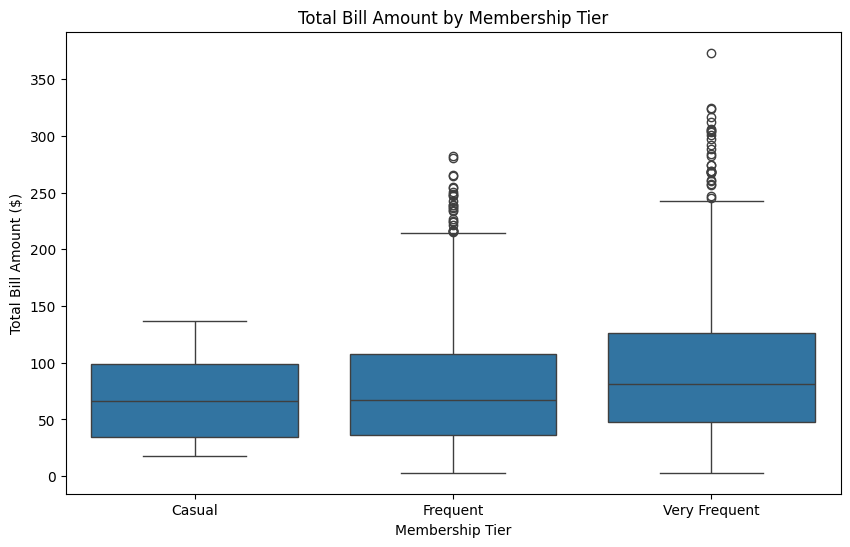

In [57]:
# Boxplot: Total Bill Amount by Membership Tier
plt.figure(figsize=(10, 6))
tier_order = ["Casual", "Frequent", "Very Frequent"]
sns.boxplot(data=orders_with_tier, x="tier", y="total_bill_amount", order=tier_order)
plt.title("Total Bill Amount by Membership Tier")
plt.xlabel("Membership Tier")
plt.ylabel("Total Bill Amount ($)")
plt.show()


In [58]:
# Summary statistics by tier
summary_stats = orders_with_tier.groupby("tier")[["time_spent_min", "total_bill_amount"]].agg([
    "mean", "median", "std", "min", "max"
]).round(2)

print("Summary Statistics: Time Spent and Total Bill by Membership Tier")
print(summary_stats)


Summary Statistics: Time Spent and Total Bill by Membership Tier
              time_spent_min                        total_bill_amount         \
                        mean median    std min  max              mean median   
tier                                                                           
Casual                113.00  112.0  37.41  67  175             69.44  66.55   
Frequent               99.73  100.0  35.09  30  217             76.98  67.44   
Very Frequent         101.85  102.0  36.05  30  239             93.12  81.24   

                                     
                 std    min     max  
tier                                 
Casual         43.93  17.48  136.97  
Frequent       51.75   2.99  282.43  
Very Frequent  60.40   2.99  373.24  


In [59]:
# Extract email provider from orders
orders["email_provider"] = orders["email"].str.split("@").str[1].str.split(".").str[0]

# Display provider distribution
print("Email provider distribution in orders:")
print(orders["email_provider"].value_counts())


Email provider distribution in orders:
email_provider
hotmail    970
outlook    964
yahoo      934
icloud     890
gmail      742
Name: count, dtype: int64


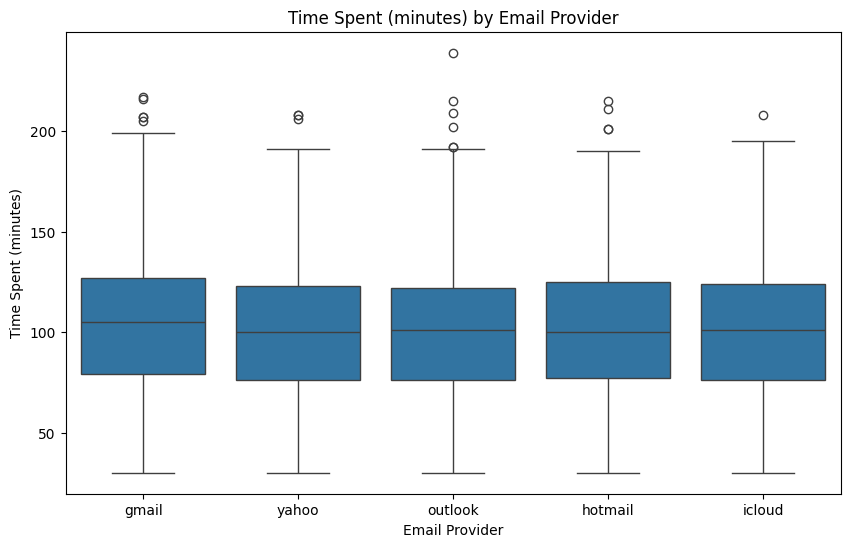

In [60]:
# Boxplot: Time Spent by Email Provider
plt.figure(figsize=(10, 6))
provider_order = ["gmail", "yahoo", "outlook", "hotmail", "icloud"]
sns.boxplot(data=orders, x="email_provider", y="time_spent_min", order=provider_order)
plt.title("Time Spent (minutes) by Email Provider")
plt.xlabel("Email Provider")
plt.ylabel("Time Spent (minutes)")
plt.show()


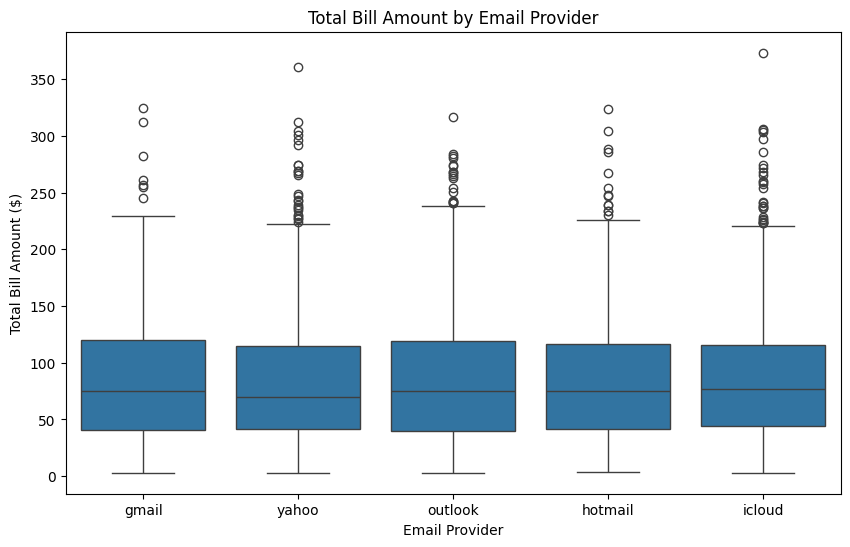

In [61]:
# Boxplot: Total Bill Amount by Email Provider
plt.figure(figsize=(10, 6))
provider_order = ["gmail", "yahoo", "outlook", "hotmail", "icloud"]
sns.boxplot(data=orders, x="email_provider", y="total_bill_amount", order=provider_order)
plt.title("Total Bill Amount by Email Provider")
plt.xlabel("Email Provider")
plt.ylabel("Total Bill Amount ($)")
plt.show()


In [65]:
# Summary statistics by email provider
provider_summary = orders.groupby("email_provider")[["time_spent_min", "total_bill_amount"]].agg([
    "mean", "median", "std", "min", "max"
]).round(2)

print("Summary Statistics: Time Spent and Total Bill by Email Provider")
print(provider_summary)


Summary Statistics: Time Spent and Total Bill by Email Provider
               time_spent_min                        total_bill_amount         \
                         mean median    std min  max              mean median   
email_provider                                                                  
gmail                  103.88  105.0  37.04  30  217             85.01  75.44   
hotmail                100.85  100.0  34.18  30  215             85.10  74.69   
icloud                 100.95  101.0  34.94  30  208             85.72  76.62   
outlook                100.45  101.0  35.52  30  239             85.23  74.70   
yahoo                   99.85  100.0  34.33  30  208             83.87  70.12   

                                     
                  std   min     max  
email_provider                       
gmail           55.36  2.99  324.33  
hotmail         55.68  3.29  323.88  
icloud          56.29  2.99  373.24  
outlook         57.40  2.99  316.49  
yahoo           57.35

In [68]:
# Total vs Average vs Median spend by email provider
spend_compare = (
    orders.groupby("email_provider")["total_bill_amount"]
    .agg(total_spend="sum", avg_spend="mean", median_spend="median", order_count="count")
    .round({"total_spend": 2, "avg_spend": 2, "median_spend": 2})
    .sort_values("total_spend", ascending=False)
)

print("Total vs Average vs Median Spend by Email Provider (CAD):")
print(spend_compare)


Total vs Average vs Median Spend by Email Provider (CAD):
                total_spend  avg_spend  median_spend  order_count
email_provider                                                   
hotmail            82542.15      85.10         74.69          970
outlook            82157.29      85.23         74.70          964
yahoo              78332.83      83.87         70.12          934
icloud             76293.63      85.72         76.62          890
gmail              63075.85      85.01         75.44          742


In [69]:
# Derive area_code from customers' phone (e.g., '1-365-227-6804' -> '365')
customers = customers.copy()
customers["area_code"] = customers["phone"].str.split("-").str[1]

# Basic counts of customers by area code
area_code_counts = customers["area_code"].value_counts()
print("Customer counts by area code:")
print(area_code_counts)


Customer counts by area code:
area_code
905    97
365    87
647    84
437    79
289    78
416    75
Name: count, dtype: int64


In [70]:
# Attach area_code to orders and compute spend/time stats
orders_with_area = orders.merge(customers[["email", "area_code"]], on="email", how="left")

area_spend_summary = (
    orders_with_area.groupby("area_code")["total_bill_amount"]
    .agg(total_spend="sum", avg_spend="mean", median_spend="median", order_count="count")
    .round({"total_spend": 2, "avg_spend": 2, "median_spend": 2})
)

area_time_summary = (
    orders_with_area.groupby("area_code")["time_spent_min"]
    .agg(total_time_spent="sum", avg_time="mean", median_time="median")
    .round({"total_time_spent": 0, "avg_time": 2, "median_time": 2})
)

# Merge spend and time summaries
area_order_summary = (
    area_spend_summary.merge(area_time_summary, left_index=True, right_index=True)
    .sort_values("total_spend", ascending=False)
)

print("Orders summary by area code (spend and time):")
print(area_order_summary.head(20))


Orders summary by area code (spend and time):
           total_spend  avg_spend  median_spend  order_count  \
area_code                                                      
905           74514.89      83.82         72.47          889   
365           67032.06      83.79         73.96          800   
437           63127.65      86.71         76.15          728   
647           61318.10      85.76         73.71          715   
289           61060.42      85.88         71.96          711   
416           55348.63      84.24         76.94          657   

           total_time_spent  avg_time  median_time  
area_code                                           
905                   89293    100.44         99.0  
365                   81302    101.63        103.0  
437                   72275     99.28         98.0  
647                   72979    102.07        102.0  
289                   72846    102.46        103.0  
416                   66153    100.69        101.0  


In [71]:
# Membership tier distribution by area code (among members only)
# Attach area_code to members via customers, then compute tier counts and rates
members_with_area = members.merge(customers[["email", "area_code"]], on="email", how="left")

# Counts per tier
tier_counts_by_area = pd.crosstab(members_with_area["area_code"], members_with_area["tier"]).sort_index()

# Row-wise percentages
tier_rates_by_area = tier_counts_by_area.div(tier_counts_by_area.sum(axis=1), axis=0) * 100

tier_counts_and_rates = tier_counts_by_area.join(
    tier_rates_by_area.add_suffix("_rate")
)

print("Membership tier counts and rates by area code (members only):")
print(tier_counts_and_rates.head(20).round(2))


Membership tier counts and rates by area code (members only):
tier       Casual  Frequent  Very Frequent  Casual_rate  Frequent_rate  \
area_code                                                                
289             0        26             25         0.00          50.98   
365             1        31             21         1.89          58.49   
416             0        31             18         0.00          63.27   
437             1        28             18         2.13          59.57   
647             1        31             18         2.00          62.00   
905             0        32             26         0.00          55.17   

tier       Very Frequent_rate  
area_code                      
289                     49.02  
365                     39.62  
416                     36.73  
437                     38.30  
647                     36.00  
905                     44.83  


In [ ]:
# Group area codes into two groups and recompute summaries
TORONTO_CORE = {"416", "647", "437"}
OUTER_BELT = {"905", "289", "365"}

# Ensure customers has area_code
if "area_code" not in customers.columns:
    customers = customers.copy()
    customers["area_code"] = customers["phone"].str.split("-").str[1]

# Map to area_group on customers
customers = customers.copy()
customers["area_group"] = customers["area_code"].map(
    lambda ac: "Toronto Core (416/647/437)" if ac in TORONTO_CORE
    else ("Outer Belt (905/289/365)" if ac in OUTER_BELT else "Other")
)

# Counts of customers by group
print("Customer counts by area group:")
print(customers["area_group"].value_counts())

# Attach area_group to orders
orders_with_area_group = orders.merge(customers[["email", "area_group"]], on="email", how="left")

# Spend/time summaries by area_group
group_spend_summary = (
    orders_with_area_group.groupby("area_group")["total_bill_amount"]
    .agg(total_spend="sum", avg_spend="mean", median_spend="median", order_count="count")
    .round({"total_spend": 2, "avg_spend": 2, "median_spend": 2})
)

group_time_summary = (
    orders_with_area_group.groupby("area_group")["time_spent_min"]
    .agg(total_time_spent="sum", avg_time="mean", median_time="median")
    .round({"total_time_spent": 0, "avg_time": 2, "median_time": 2})
)

area_group_order_summary = group_spend_summary.merge(group_time_summary, left_index=True, right_index=True)
print("\nOrders summary by area group:")
print(area_group_order_summary.sort_values("total_spend", ascending=False))

# Tier distribution by area_group among members
members_with_area_group = members.merge(customers[["email", "area_group"]], on="email", how="left")

tier_counts_by_group = pd.crosstab(members_with_area_group["area_group"], members_with_area_group["tier"]).sort_index()
tier_rates_by_group = tier_counts_by_group.div(tier_counts_by_group.sum(axis=1), axis=0) * 100

tier_counts_and_rates_group = tier_counts_by_group.join(tier_rates_by_group.add_suffix("_rate"))
print("\nMembership tier counts and rates by area group:")
print(tier_counts_and_rates_group.round(2))

Customer counts by area group:
area_group
Outer Belt (905/289/365)      262
Toronto Core (416/647/437)    238
Name: count, dtype: int64

Orders summary by area group:
                            total_spend  avg_spend  median_spend  order_count  \
area_group                                                                      
Outer Belt (905/289/365)      202607.37      84.42         72.90         2400   
Toronto Core (416/647/437)    179794.38      85.62         75.43         2100   

                            total_time_spent  avg_time  median_time  
area_group                                                           
Outer Belt (905/289/365)              243441    101.43        102.0  
Toronto Core (416/647/437)            211407    100.67        100.0  

Membership tier counts and rates by area group:
tier                        Casual  Frequent  Very Frequent  Casual_rate  \
area_group                                                                 
Outer Belt (905/289/365)   

: 

In [ ]:
# Weekday distribution by Email Provider
weekday_provider_crosstab = pd.crosstab(orders["email_provider"], orders["weekday"])
weekday_provider_percentage = weekday_provider_crosstab.div(weekday_provider_crosstab.sum(axis=1), axis=0) * 100

print("Weekday distribution by Email Provider (Row Percentages):")
print(weekday_provider_percentage.round(2))


In [ ]:
# Weekday distribution by Email Provider - Heatmap
plt.figure(figsize=(12, 6))
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
provider_order = ["gmail", "yahoo", "outlook", "hotmail", "icloud"]
sns.heatmap(weekday_provider_percentage.loc[provider_order, weekday_order], annot=True, fmt=".1f", cmap="YlOrRd", cbar_kws={"label": "Percentage (%)"})
plt.title("Weekday Distribution by Email Provider (Row Percentages)")
plt.xlabel("Weekday")
plt.ylabel("Email Provider")
plt.tight_layout()
plt.show()


In [ ]:
# Weekday distribution by Area Code
weekday_area_crosstab = pd.crosstab(orders_with_area["area_code"], orders_with_area["weekday"])
weekday_area_percentage = weekday_area_crosstab.div(weekday_area_crosstab.sum(axis=1), axis=0) * 100

print("Weekday distribution by Area Code (Row Percentages):")
print(weekday_area_percentage.round(2))


In [ ]:
# Weekday distribution by Area Code - Heatmap
plt.figure(figsize=(12, 6))
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
area_order = sorted(weekday_area_percentage.index)  # Sort by area code
sns.heatmap(weekday_area_percentage.loc[area_order, weekday_order], annot=True, fmt=".1f", cmap="YlOrRd", cbar_kws={"label": "Percentage (%)"})
plt.title("Weekday Distribution by Area Code (Row Percentages)")
plt.xlabel("Weekday")
plt.ylabel("Area Code")
plt.tight_layout()
plt.show()


In [ ]:
# Weekday distribution by Area Group (Toronto Core vs Outer Belt)
weekday_area_group_crosstab = pd.crosstab(orders_with_area_group["area_group"], orders_with_area_group["weekday"])
weekday_area_group_percentage = weekday_area_group_crosstab.div(weekday_area_group_crosstab.sum(axis=1), axis=0) * 100

print("Weekday distribution by Area Group (Row Percentages):")
print(weekday_area_group_percentage.round(2))


In [ ]:
# Weekday distribution by Area Group - Heatmap
plt.figure(figsize=(12, 4))
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
group_order = ["Toronto Core (416/647/437)", "Outer Belt (905/289/365)"]
sns.heatmap(weekday_area_group_percentage.loc[group_order, weekday_order], annot=True, fmt=".1f", cmap="YlOrRd", cbar_kws={"label": "Percentage (%)"})
plt.title("Weekday Distribution by Area Group (Row Percentages)")
plt.xlabel("Weekday")
plt.ylabel("Area Group")
plt.tight_layout()
plt.show()
